In [22]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit

X , y = load_diabetes(return_X_y=True , as_frame=True)

shuffle_split = ShuffleSplit(n_splits=5 , test_size=0.2 , random_state=42)

lin_reg = LinearRegression()

LearningCurve = learning_curve(

    lin_reg , X , y , cv=shuffle_split,
    scoring="neg_mean_absolute_error",

)

train_sizes , train_score , test_score = LearningCurve

In [14]:
train_score , test_score = -train_score , -test_score

In [19]:
print(train_size)
print(train_score)
print(test_score)

[ 35 114 194 273 353]
[[32.4537313  28.33964115 37.58204042 38.02965759 39.27996846]
 [40.22021215 45.58098479 40.62892039 38.98436045 45.98759828]
 [42.81789706 45.4372641  43.45018875 41.08786485 43.22570042]
 [42.57103829 44.19220153 43.76197156 41.24237614 43.54088918]
 [43.48350352 43.90847346 43.40515711 42.10326561 42.7099285 ]]
[[47.71331292 50.04458508 47.71685957 54.42976467 58.90513213]
 [44.11024282 43.0593055  47.16570212 50.02438309 45.36893437]
 [43.04221385 41.21958803 42.92971615 48.47421319 46.27677781]
 [42.69401879 41.04487887 43.07671799 48.53349105 45.56968428]
 [42.79409468 41.02966715 43.71417907 48.214139   45.68240405]]


In [25]:
train_mean = train_score.mean(axis=1)
test_mean = test_score.mean(axis=1)

train_std = train_score.std(axis=1)
test_std = test_score.std(axis=1)

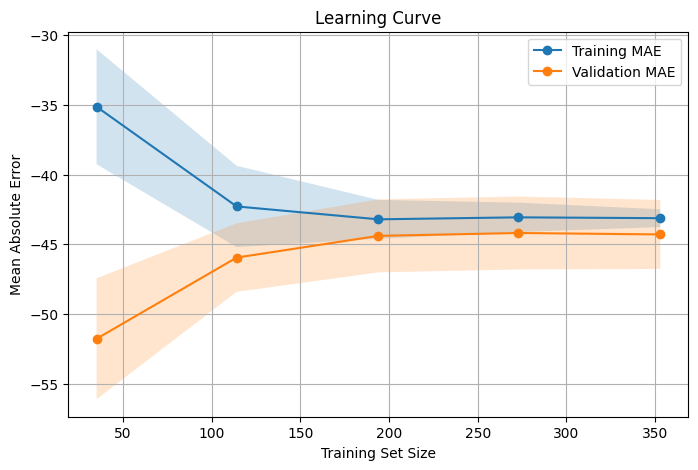

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, marker='o', label='Training MAE')
plt.plot(train_sizes, test_mean, marker='o', label='Validation MAE')

plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    test_mean-test_std,
    test_mean+test_std,
    alpha=0.2
)

plt.xlabel("Training Set Size")
plt.ylabel("Mean Absolute Error")
plt.title("Learning Curve")

plt.grid(True)
plt.legend()

plt.show()